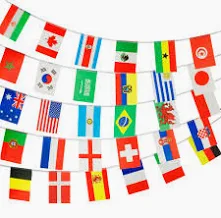

<p style="text-align: center; font-size: 28px;"><b>Prediting the continent of origin based on the characte</b></p>

Can you guess which continent this flag comes from?

Flag of Reunion
What are some of the features that would clue you in? Maybe some of the colors are good indicators. The presence or absence of certain shapes could give you a hint. In this project, we’ll use decision trees to try to predict the continent of flags based on several of these features.

We’ll explore which features are the best to use and the best way to create your decision tree.

In [359]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# Investigate the data 

<p style="font-size: 18px;"><b>Task 1: Dataset Overview</b></p>

The dataset has already been imported in `script.py` as a DataFrame named `df`.  
It describes the attributes of national flags, with both input features and the output variable of interest.  

Key variables include:

- **name**: country name  
- **landmass**: continent identifier  
  - 1 = North America  
  - 2 = South America  
  - 3 = Europe  
  - 4 = Africa  
  - 5 = Asia  
  - 6 = Oceania  
- **bars**: number of vertical bars  
- **stripes**: number of horizontal stripes  
- **colours**: total number of colours in the flag  
- **red**: 1 if the flag contains red, otherwise 0  
- **mainhue**: predominant flag colour, determined by tie-breaking rules  
- **circles**: number of circles  
- **crosses**: number of upright crosses  
- **saltires**: number of diagonal crosses  
- **quarters**: number of quartered sections  
- **sunstars**: number of sun or star symbols  

The objective is to construct a **decision tree classifier** that predicts a country’s continent (`landmass`) from its flag characteristics.  

Before training the model, we begin by exploring the dataset to understand the **distribution of flags per continent**, by calculating the count of entries for each `landmass` value.


In [360]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [361]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
flags = fetch_ucirepo(id=40) 
  
# data (as pandas dataframes) 
X = flags.data.features 
y = flags.data.targets 

In [362]:
# metadata 
print(flags.metadata) 

{'uci_id': 40, 'name': 'Flags', 'repository_url': 'https://archive.ics.uci.edu/dataset/40/flags', 'data_url': 'https://archive.ics.uci.edu/static/public/40/data.csv', 'abstract': 'From Collins Gem Guide to Flags, 1986', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 194, 'num_features': 30, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Other'], 'target_col': None, 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1990, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C52C7Z', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': 'This data file contains details of various nations and their flags. In this file the fields are separated by spaces (not commas).  With this data you can try things like predicting the religion of a country from its size and the colours in its flag.  \r\n\r\n10 attributes are numeric-valued.  The remainder are e

In [363]:
# variable information 
print(flags.variables) 

          name     role         type demographic description units  \
0         name  Feature  Categorical       Other        None  None   
1     landmass  Feature      Integer        None        None  None   
2         zone  Feature      Integer        None        None  None   
3         area  Feature      Integer        None        None  None   
4   population  Feature      Integer        None        None  None   
5     language  Feature      Integer       Other        None  None   
6     religion  Feature      Integer       Other        None  None   
7         bars  Feature      Integer        None        None  None   
8      stripes  Feature      Integer        None        None  None   
9      colours  Feature      Integer        None        None  None   
10         red  Feature      Integer        None        None  None   
11       green  Feature      Integer        None        None  None   
12        blue  Feature      Integer        None        None  None   
13        gold  Feat

In [364]:
print("The dataset has " + str(len(X.columns)) + " columns.")

The dataset has 30 columns.


In [365]:
cols = ['name','landmass','zone', 'area', 'population', 'language','religion','bars','stripes','colours',
'red','green','blue','gold','white','black','orange','mainhue','circles',
'crosses','saltires','quarters','sunstars','crescent','triangle','icon','animate','text','topleft','botright']

bool_value = True
for col1 in X.columns:
    if col1 not in cols:
         bool_value = False
    else: 
        bool_value = True
print("All columns are represented:" ,bool_value)

All columns are represented: True


<p style="font-size: 18px;"><b>Task 2: Subset the Data for Europe and Oceania</b></p>

From the full dataset, restrict the analysis to only two continents — **Europe** and **Oceania**.  
Create a new DataFrame that contains exclusively the flags belonging to these regions.



In [366]:
#X.head()

In [367]:
#df_36 = X[(X["landmass"] == 3) | (X["landmass"] == 6)]
#len(df_36)

In [368]:
#df_36.landmass.unique()

<p style="font-size: 18px;"><b>Task 3: Compare Predictor Averages</b></p>

Using the predictors defined in the list `var`, calculate and print the average value of each predictor for the continents **Europe** and **Oceania**.
Identify and highlight which predictors show the largest differences in their average values between the two regions.

In [369]:
#variable names to use as predictors
var = [ 'red', 'green', 'blue','gold', 'white', 'black', 'orange', 'bars','stripes', 'circles','crosses', 'saltries','quarters','sunstars','triangle','animate']

In [370]:
print(X.groupby('landmass')[var].mean().T)

landmass         1         2         3         4         5     6
red       0.677419  0.764706  0.828571  0.807692  0.820513  0.80
green     0.419355  0.411765  0.200000  0.826923  0.435897  0.20
blue      0.774194  0.705882  0.514286  0.307692  0.333333  0.80
gold      0.516129  0.647059  0.428571  0.519231  0.256410  0.60
white     0.838710  0.823529  0.771429  0.538462  0.820513  0.95
black     0.354839  0.235294  0.171429  0.326923  0.282051  0.15
orange    0.193548  0.058824  0.057143  0.134615  0.179487  0.15
bars      0.580645  0.352941  0.628571  0.673077  0.179487  0.00
stripes   1.451613  2.176471  1.285714  1.942308  1.666667  0.40
circles   0.193548  0.176471  0.028571  0.115385  0.358974  0.15
crosses   0.225806  0.058824  0.285714  0.038462  0.025641  0.40
saltries  0.193548  0.058824  0.028571  0.057692  0.025641  0.30
quarters  0.193548  0.411765  0.028571  0.057692  0.102564  0.40
sunstars  2.806452  2.117647  0.142857  0.576923  1.153846  3.30
triangle  0.258065  0.117

<p style="font-size: 18px;"><b>Task 4: Inspect Predictor Variable Types</b></p>

Before building a classifier to differentiate between flags from **Europe** and **Oceania**, examine the variable types of each predictor.
Determine whether they are numerical, categorical, or binary to guide the choice of preprocessing and modeling techniques.

In [371]:
labels = (X["landmass"])*1

In [372]:
X.dtypes

name          object
landmass       int64
zone           int64
area           int64
population     int64
language       int64
religion       int64
bars           int64
stripes        int64
colours        int64
red            int64
green          int64
blue           int64
gold           int64
white          int64
black          int64
orange         int64
mainhue       object
circles        int64
crosses        int64
saltries       int64
quarters       int64
sunstars       int64
crescent       int64
triangle       int64
icon           int64
animate        int64
text           int64
topleft       object
botright      object
dtype: object

<p style="font-size: 18px;"><b>Task 5: Transform Predictors into Dummy Variables</b></p>

All predictor variables are numeric except for **mainhue**.
Convert the **mainhue** categorical variable into dummy variables, then store the transformed predictor dataset in a new DataFrame named `data`.

In [373]:
#variable names to use as predictors
var = [ 'red', 'green', 'blue','gold', 'white', 'black', 'orange', 'mainhue','bars','stripes', 'circles','crosses', 'saltries','quarters','sunstars','triangle','animate']

In [374]:
data = pd.get_dummies(X[var])

In [375]:
data.dtypes

red               int64
green             int64
blue              int64
gold              int64
white             int64
black             int64
orange            int64
bars              int64
stripes           int64
circles           int64
crosses           int64
saltries          int64
quarters          int64
sunstars          int64
triangle          int64
animate           int64
mainhue_black      bool
mainhue_blue       bool
mainhue_brown      bool
mainhue_gold       bool
mainhue_green      bool
mainhue_orange     bool
mainhue_red        bool
mainhue_white      bool
dtype: object

In [376]:
data.head()

,red,green,blue,gold,white,black,orange,bars,stripes,circles,...,triangle,animate,mainhue_black,mainhue_blue,mainhue_brown,mainhue_gold,mainhue_green,mainhue_orange,mainhue_red,mainhue_white
0,1,1,0,1,1,1,0,0,3,0,...,0,0,False,False,False,False,True,False,False,False
1,1,0,0,1,0,1,0,0,0,0,...,0,1,False,False,False,False,False,False,True,False
2,1,1,0,0,1,0,0,2,0,0,...,0,0,False,False,False,False,True,False,False,False
3,1,0,1,1,1,0,1,0,0,0,...,1,1,False,True,False,False,False,False,False,False
4,1,0,1,1,0,0,0,3,0,0,...,0,0,False,False,False,True,False,False,False,False


<p style="font-size: 18px;"><b>Task 6: Split Data into Training and Test Sets</b></p>

Divide the prepared dataset into a **training set** and a **test set**.
The training set will be used to fit the model, while the test set will be reserved for evaluating its performance.


In [377]:
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, random_state=1, test_size=.4)

In [378]:
print(len(train_data))
print(len(test_data))
print(len(train_labels))
print(len(test_labels))

116
78
116
78


# Tune Decision Tree Classifiers by Depth

<p style="font-size: 18px;"><b>Task 7: Tune Decision Tree with Varying Depths</b></p>

Train a Decision Tree Classifier using `max_depth` values ranging from **1 to 20**.
For each depth, compute and record the accuracy score on the test set.
Store the results in a list named `acc_depth`.


In [379]:
acc_depth = []
depths = range(1, 21)
for i in depths:
    dtree = DecisionTreeClassifier(max_depth = i, random_state = 10,)
    dtree.fit(train_data, train_labels)
    acc_score = dtree.score(test_data, test_labels)
    acc_depth.append(acc_score)

<p style="font-size: 18px;"><b>Task 8: Plot Accuracy vs. Tree Depth</b></p>

Create a plot with **max_depth** values on the x-axis and the corresponding **accuracy scores** from `acc_depth` on the y-axis.
This visualization will help identify the depth that provides the best balance between model complexity and performance.


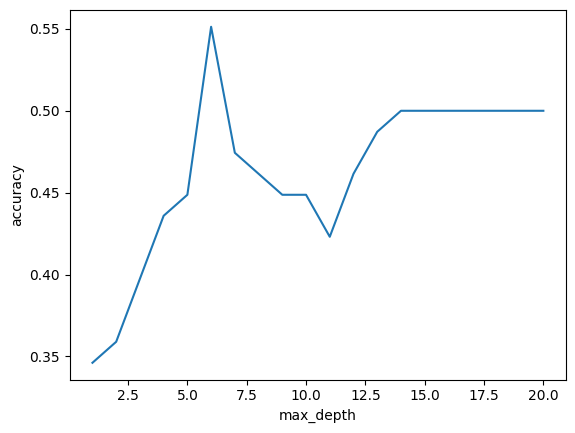

In [380]:
#Plot the accuracy vs depth
plt.plot(depths, acc_depth)
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.show()

<p style="font-size: 18px;"><b>🔑 Key Remarks</b></p>  

When working with a **small dataset**, the test set can be very limited in size.
As a result, accuracy may occasionally spike to **1.0 purely by chance**, rather than reflecting true model performance.


<p style="font-size: 18px;"><b>Task 9: Identify Maximum Accuracy and Corresponding Depth</b></p>

Determine the **highest accuracy score** achieved among the tested models and record the **max_depth value** at which this peak performance occurs.


In [381]:
max_acc = np.max(acc_depth)
index = acc_depth.index(max_acc)
best_depth = depths[index]

In [382]:
print(f'Highest accuracy {round(max_acc,3)*100}% at depth {best_depth}')

Highest accuracy 55.1% at depth 6


<p style="font-size: 18px;"><b>Task 10: Refit and Visualize Optimal Decision Tree</b></p>

Refit the Decision Tree Classifier using the **max_depth** value identified as optimal in the previous step.
Generate and display a **plot of the decision tree**, showing its structure and splits.


In [383]:
dtree = DecisionTreeClassifier(max_depth = best_depth, random_state = 10,)
dtree.fit(train_data, train_labels)

DecisionTreeClassifier(max_depth=6, random_state=10)

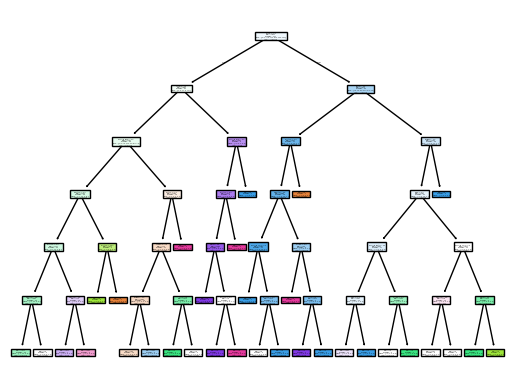

In [384]:
tree.plot_tree(dtree, feature_names = train_data.columns,  
               class_names = ['Europe', 'Oceania', "N.America", "S.America", "Africa", "Asia"],
                filled=True)
plt.show()

# Tune Decision Tree Classifiers by Pruning

<p style="font-size: 18px;"><b>Task 11: Tune Decision Tree with Pruning Parameter</b></p>

Using the hyperparameter **ccp_alpha** (cost-complexity pruning), fit a Decision Tree Classifier for each value specified in the list `ccp`.
For every fitted model, calculate the accuracy score and store the results in a list named `acc_pruned`.

In [385]:
acc_pruned = []
ccp = np.logspace(-3, 0, num=20)

In [386]:
for i in ccp:
    dt_prune = DecisionTreeClassifier(random_state = 1, max_depth = best_depth, ccp_alpha=i)
    dt_prune.fit(train_data, train_labels)
    acc_score = dt_prune.score(test_data, test_labels)
    acc_pruned.append(acc_score)

<p style="font-size: 18px;"><b>Task 12: Plot Accuracy vs. Pruning Parameter</b></p>

Create a plot with **ccp_alpha** values on the x-axis and the corresponding **accuracy scores** from `acc_pruned` on the y-axis.
This visualization will illustrate how pruning impacts the model’s performance.


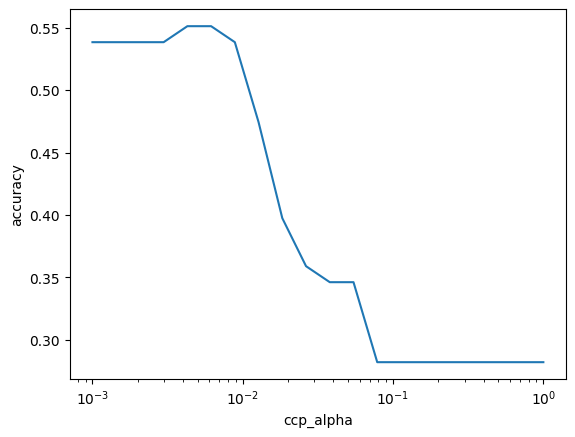

In [387]:
plt.plot(ccp, acc_pruned)
plt.xscale('log')
plt.xlabel('ccp_alpha')
plt.ylabel('accuracy')
plt.show()

<p style="font-size: 18px;"><b>Task 13: Identify Maximum Accuracy and Corresponding Pruning Value</b></p>

Determine the **highest accuracy score** obtained across the pruned models and record the **ccp_alpha** value at which this best performance occurs.


In [388]:
max_acc = np.max(acc_pruned)
index = acc_pruned.index(max_acc)
best_acc_alpha = ccp[index]

In [389]:
print(f'Highest accuracy {round(max_acc,3)*100}% at ccp_alpha {best_acc_alpha}')

Highest accuracy 55.1% at ccp_alpha 0.004281332398719396


<p style="font-size: 18px;"><b>Task 14: Fit and Visualize Final Decision Tree</b></p>

Train a Decision Tree Classifier using the **optimal values** for both `max_depth` and `ccp_alpha` identified in the previous steps.
Generate and display a **plot of the final decision tree**, showing its complete structure with the applied pruning.


In [390]:
dt_best = DecisionTreeClassifier(random_state = 1, max_depth = best_depth, ccp_alpha=best_acc_alpha)
dt_best.fit(train_data, train_labels)

DecisionTreeClassifier(ccp_alpha=np.float64(0.004281332398719396), max_depth=6,
                       random_state=1)

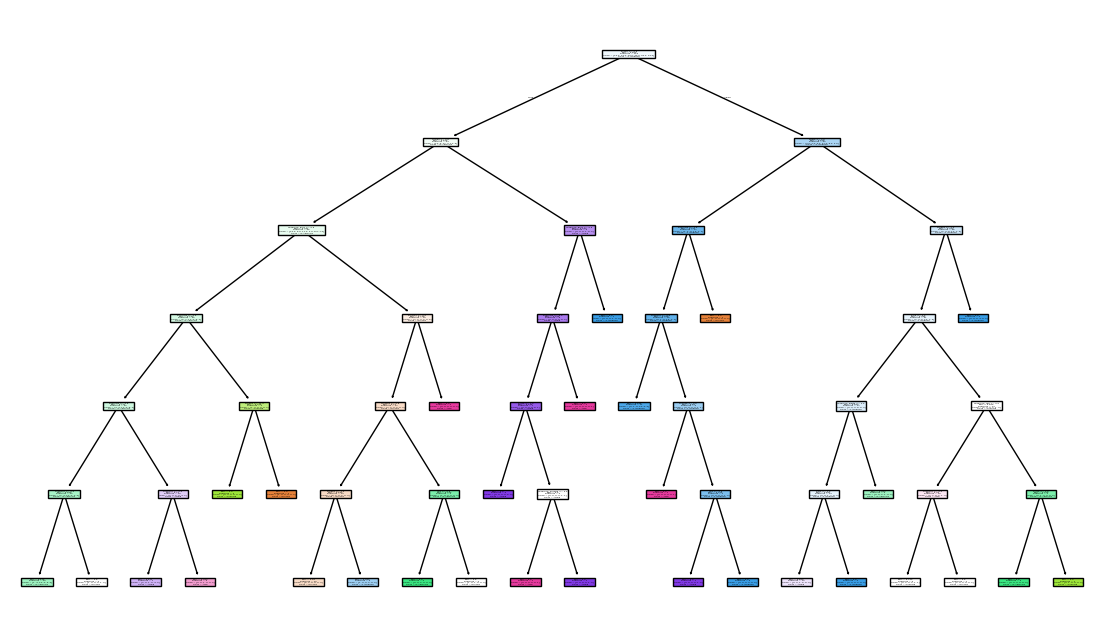

In [392]:
plt.figure(figsize=(14,8))
tree.plot_tree(dt_best, feature_names = train_data.columns,  
               class_names = ['Europe', 'Oceania', "N.America", "S.America", "Africa", "Asia"],
                filled=True)
plt.show()

<p style="font-size: 18px;"><b>Task 15: Final Model Insights and Extensions</b></p>

Great job! 🎉 The final model achieved **higher accuracy** while maintaining a **simpler tree structure** — pruning removed unnecessary branches, making the results easier to interpret.

Possible extensions for this project include:

* 🔄 **Classify a different target**: Instead of predicting *Landmass*, try predicting another feature such as *Language*.

In [393]:
labels = (X["language"])*1

In [394]:
train_data, test_data, train_labels, test_labels = train_test_split(data, labels, random_state=1, test_size=.4)

In [395]:
dt_best = DecisionTreeClassifier(random_state = 1, max_depth = best_depth, ccp_alpha=best_acc_alpha)
dt_best.fit(train_data, train_labels)

DecisionTreeClassifier(ccp_alpha=np.float64(0.004281332398719396), max_depth=6,
                       random_state=1)